# Iteración 14: Modelos base entrenados también sin las reseñas indecisas
**Curso:** Aprendizaje de Máquina 2026-20, Universidad de los Andes · **Parte 1** (ML clásico, solo scikit-learn)

Envío a Kaggle: `kaggle_iteraciones/iter14_bases_sin_indecisas.csv` · Modelo: `models/iteraciones/iter14_bases_sin_indecisas.joblib`

**Qué cambia respecto a la iteración anterior.** El stack de la iteración 13 tenía 15 modelos base. Aquí se le agregan **14 más: los mismos modelos, pero entrenados sin las reseñas que cierran con una frase de indecisión** ("tengo sentimientos encontrados", "cada quien que juzgue"). El metamodelo (`HistGradientBoosting`) es el mismo y sigue viendo todas las reseñas.

**Por qué.** Al revisar los errores de la iteración 13 se encontró que las reseñas expresan la opinión de dos maneras:
- **Con un adjetivo** ("la pantalla resultó frágil", "el acabado luce impecable"). Si hay dos opiniones opuestas, la etiqueta es siempre la de la **última**, con cualquier conector (2.206 casos revisados, ninguna excepción).
- **Con una frase hecha** ("me encantó la cámara de principio a fin", "el cable no vale lo que cuesta"). Con una sola frase, la etiqueta es la polaridad de la frase. Con **una positiva y una negativa**, la etiqueta es prácticamente **una moneda al aire**: 50,4 % son positivas y la última opinión gana solo el 51,5 % de las veces (1.608 reseñas). Ninguna variable del texto la predice: frases, orden, conector, frase de cierre, aspecto opinado, bolsa de palabras y n-gramas de caracteres quedan entre 0,49 y 0,52 en validación cruzada (el azar es 0,50 ± 0,01).

Esa "zona de moneda al aire" es el 17,8 % del entrenamiento, y ahí estaban **788 de los 835 errores** de la iteración 13; en el resto de las reseñas ya acertaba el 99,4 %. Las frases de cierre indeciso solo aparecen en esa zona. Para los modelos base esas reseñas son **ruido**: su etiqueta positivo/negativo no dice nada sobre las palabras que contienen y ensucia los pesos que aprende cada regresión logística. Entrenar una segunda copia de cada modelo base sin ellas da pesos más limpios; el stack conserva las dos copias y el metamodelo decide cuánto usar cada una.

**Cómo se decidió.** Dentro de la zona cualquier modelo acierta cerca del 50 %, así que lo que un modelo gana o pierde ahí es suerte. El cambio se aceptó por los **errores fuera de la zona**, medidos en validaciones cruzadas con cuatro particiones distintas del entrenamiento (siempre los mismos pliegues para los dos modelos):

| Semilla de la partición | Errores fuera de la zona (iteración 13 → 14) | Errores totales (iteración 13 → 14) |
|---|---|---|
| 42 | 47 → 41 | 835 → 818 |
| 2026 | 52 → 44 | 860 → 841 |
| 7 | 50 → 39 | 850 → 832 |
| 99 (no se usó para elegir) | 56 → 51 | 843 → 856 |

Fuera de la zona mejora en las cuatro particiones (205 → 175 errores en total). El total mejora en tres y empeora en la cuarta, que es lo esperable cuando el total lo domina el azar de la zona.

> La zona se identificó con una lista de frases escrita a mano que se usó **solo para medir**, en un análisis aparte que no está en este notebook. **El modelo no usa esa lista** ni ningún léxico de sentimiento: lo único escrito a mano son listas estructurales (conectores, negadores y frases de indecisión).

## 1. Configuración

In [1]:
import os

# Un solo hilo en las librerías numéricas, ANTES de importar numpy/sklearn: el clasificador de segmentos de
# polaridad_segmentos (liblinear) da resultados ligeramente distintos según el número de hilos BLAS, y con
# 1 hilo el modelo es idéntico en cualquier máquina (todas las cifras se midieron así).
for variable in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ[variable] = "1"


import re
import unicodedata
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import LinearSVC

SEED = 42  # semilla fija: todo el notebook es replicable
np.random.seed(SEED)

# Funciona igual si el notebook se abre desde la raíz del proyecto o desde notebooks_iteraciones/
RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_DIR = RAIZ / "data"
ENVIOS_DIR = RAIZ / "kaggle_iteraciones"        # archivos para subir a Kaggle
MODELOS_DIR = RAIZ / "models" / "iteraciones"   # modelo de cada iteración (joblib)
ENVIOS_DIR.mkdir(exist_ok=True)
MODELOS_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ["negativo", "neutral", "positivo"]
print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__)

scikit-learn 1.9.1 | pandas 3.0.6


## 2. Datos y corrección del texto
La misma corrección de `parte1convencional.ipynb` (sección 3.7): reparar la codificación dañada, quitar guiones invisibles, minúsculas y quitar tildes. Va **dentro** del modelo (como `preprocessor` o dentro de las funciones de cada vista), así que el modelo guardado recibe el texto original.

Partición igual que en `parte1convencional.ipynb`: 80 % entrenamiento / 20 % prueba, estratificada con `SEED = 42`. Las decisiones se toman con validación cruzada de 5 pliegues sobre el 80 %; la prueba solo se usa una vez, en la última iteración.

In [2]:
# Pares que deja una codificación dañada (UTF-8 leído como Latin-1) -> letra correcta
MOJIBAKE = {"Ã¡": "á", "Ã©": "é", "Ã\xad": "í", "Ã³": "ó", "Ãº": "ú", "Ã±": "ñ"}
# Variante en la que además la Ã perdió su tilde: "llegA3" -> "llegó"
MOJIBAKE_DEGRADADO = {"A¡": "á", "A©": "é", "A\xad": "í", "A3": "ó", "A³": "ó", "Aº": "ú", "A±": "ñ"}
PATRON_DEGRADADO = re.compile(r"(?<=[a-zñ])A[¡©\xad3³º±]")  # solo dentro de una palabra


def reparar_par(coincidencia):
    return MOJIBAKE_DEGRADADO[coincidencia.group()]


def corregir_texto(texto):
    """Devuelve una copia corregida del texto. No modifica el original."""
    for malo, bueno in MOJIBAKE.items():                 # 1. reparar la codificación dañada
        texto = texto.replace(malo, bueno)
    texto = PATRON_DEGRADADO.sub(reparar_par, texto)
    texto = texto.replace("\xad", "")                    # 2. quitar guiones invisibles
    texto = texto.lower()                                # 3. minúsculas
    texto = unicodedata.normalize("NFKD", texto)         # 4. quitar tildes y ñ
    return "".join(c for c in texto if not unicodedata.combining(c))


train = pd.read_csv(DATA_DIR / "train.csv")
eval_df = pd.read_csv(DATA_DIR / "eval.csv")  # solo para predecir, nunca para entrenar
muestra = pd.read_csv(DATA_DIR / "sample_submission.csv")

X_ent, X_prueba, y_ent, y_prueba = train_test_split(
    train["text"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"Entrenamiento: {len(X_ent)} | Prueba (sin tocar): {len(X_prueba)} | eval: {len(eval_df)}")

Entrenamiento: 9600 | Prueba (sin tocar): 2400 | eval: 3000


### Funciones para partir la reseña
El EDA mostró que el sentimiento global lo decide sobre todo **la opinión del final** (después de conectores como "aun así", "eso sí", "al final"). Estas funciones extraen partes del texto; después cada parte se representa con TF-IDF, como cualquier texto. Se definen con `def` en el notebook (no `lambda`) para que el modelo se pueda guardar y volver a cargar.

> ⚠️ Partir el texto antes de vectorizar sigue usando solo TF-IDF y clasificadores de scikit-learn, pero conviene **confirmarlo con la profesora o el monitor** antes de entregar un modelo de este tipo.

In [3]:
CONECTORES = ["aun asi", "eso si", "por otro lado", "por cierto", "de paso", "al final", "con todo",
              "a fin de cuentas", "sin embargo", "en fin", "despues de todo", "pero", "aunque", "ahora",
              "ademas", "no obstante", "de todas formas", "igual", "lo unico", "nada mas"]
PATRON_CONECTOR = re.compile(r"\b(" + "|".join(CONECTORES) + r")\b")
PATRON_ORACION = re.compile(r"(?<=[.;:!?])\s+")


def oraciones(texto):
    """Parte un texto ya corregido en oraciones."""
    return [o for o in PATRON_ORACION.split(texto.strip()) if o]


def texto_completo(textos):
    return [corregir_texto(t) for t in textos]


def ultima_oracion(textos):
    return [oraciones(corregir_texto(t))[-1] for t in textos]


def tras_ultimo_conector(textos):
    """Lo que va desde el último conector hasta el final (o la última oración si no hay conector)."""
    salida = []
    for t in textos:
        t = corregir_texto(t)
        conectores = list(PATRON_CONECTOR.finditer(t))
        salida.append(t[conectores[-1].start():] if conectores else oraciones(t)[-1])
    return salida


def vista(funcion, **parametros):
    """Una vista del texto: extraer una parte de la reseña y representarla con TF-IDF."""
    return Pipeline([("parte", FunctionTransformer(funcion)),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2, **parametros))])


print(ultima_oracion(X_ent[:1])[0])
print(tras_ultimo_conector(X_ent[:1])[0])

por cierto, trae garantia de un ano.
por cierto, trae garantia de un ano.


### Más vistas y modelos base del stacking
- **Primera y penúltima oración:** en las reseñas mixtas, la opinión del inicio también cuenta.
- **Palabras marcadas con su conector:** "feliz" después de "aun así" se vuelve `aunasi_feliz`, distinta de `porotrolado_feliz`, para que el modelo aprenda qué conectores hacen ganar a lo que sigue.
- **Cierre indeciso:** si la reseña termina con "tengo sentimientos encontrados", "ni fu ni fa" o similares. En esas reseñas el final no es una opinión y la etiqueta es más difícil de predecir.

In [4]:
def primera_oracion(textos):
    return [oraciones(corregir_texto(t))[0] for t in textos]


def penultima_oracion(textos):
    salida = []
    for t in textos:
        partes = oraciones(corregir_texto(t))
        salida.append(partes[-2] if len(partes) > 1 else "")
    return salida


def con_conector(textos):
    """Cada palabra lleva pegado el conector que abre su oración: 'aunasi_feliz', 'porotrolado_harto', 'nada_llego'."""
    salida = []
    for t in textos:
        tokens = []
        for o in oraciones(corregir_texto(t)):
            conector = next((c for c in CONECTORES + ["la verdad"] if o.startswith(c)), "nada").replace(" ", "")
            tokens += [f"{conector}_{p}" for p in re.findall(r"\w\w+", o)]
        salida.append(" ".join(tokens))
    return salida


CIERRE = re.compile(r"sentimientos encontrados|con dudas|no me decido|cada quien|a criterio|ni lo mejor ni lo peor"
                    r"|ni tan bueno ni tan malo|hay de todo|sopes|para gustos|no se si me quedo|lo dejo a tu"
                    r"|cada cosa por su lado|nomas cuento|juzgue|no se que pensar|ahi lo dejo|mis dudas|ni fu ni fa"
                    r"|no sabria|en duda|que recomendar|de cada lado|otras no|no se bien")


def cierre_indeciso(textos):
    """Marca si la reseña cierra con una frase de indecisión ("tengo sentimientos encontrados", "ni fu ni fa")."""
    return ["cierre_si" if CIERRE.search(corregir_texto(t)) else "cierre_no" for t in textos]


def clasificador_de_vista(funcion, C=3):
    """Regresión logística entrenada con una sola vista del texto (modelo base del stacking)."""
    return Pipeline([("parte", FunctionTransformer(funcion)),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


def tres_vistas(C=3):
    """El mejor modelo de una sola etapa (iteración 08): texto completo + tras el último conector + última oración."""
    return Pipeline([("vistas", FeatureUnion([("completo", vista(texto_completo)),
                                              ("tras_conector", vista(tras_ultimo_conector)),
                                              ("ultima", vista(ultima_oracion))])),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


def modelos_base():
    return [("tres_vistas", tres_vistas()),
            ("completo", clasificador_de_vista(texto_completo)),
            ("tras_conector", clasificador_de_vista(tras_ultimo_conector)),
            ("ultima", clasificador_de_vista(ultima_oracion)),
            ("primera", clasificador_de_vista(primera_oracion)),
            ("penultima", clasificador_de_vista(penultima_oracion)),
            ("con_conector", clasificador_de_vista(con_conector)),
            ("cierre", clasificador_de_vista(cierre_indeciso, C=1))]


print(con_conector(X_ent[:1])[0][:200])

nada_lo nada_compre nada_hace nada_un nada_par nada_de nada_meses nada_por nada_internet nada_llego nada_en nada_tres nada_dias nada_desde nada_que nada_llego nada_lo nada_uso nada_para nada_el nada_g


### Modelos base adicionales
- **Última oración de opinión:** se salta las oraciones finales de relleno o de indecisión. Las palabras de opinión se aprenden en `fit`, así que en la validación cruzada se aprenden solo con la parte de entrenamiento de cada pliegue (no hay fuga de información).
- **N-gramas de caracteres:** "mdia" o "cincco" no están en el vocabulario de palabras, pero comparten trozos de 2 a 5 letras con "media" y "cinco".
- **Antes del último conector:** la opinión que el conector contradice.

In [5]:
class UltimaOpinion(BaseEstimator, TransformerMixin):
    """Última oración que contiene alguna palabra de opinión y no es un cierre indeciso.

    Las palabras de opinión se aprenden en `fit` (las `k` de mayor peso en una regresión logística
    positivo contra negativo), así que en cada pliegue se aprenden solo con su parte de entrenamiento.
    """

    def __init__(self, k=400):
        self.k = k

    def fit(self, X, y):
        y = np.asarray(y)
        polares = y != "neutral"
        vectorizador = TfidfVectorizer(min_df=3)
        M = vectorizador.fit_transform(texto_completo(np.asarray(X)[polares]))
        pesos = LogisticRegression(C=1, max_iter=3000).fit(M, y[polares]).coef_[0]
        vocabulario = vectorizador.get_feature_names_out()
        self.palabras_opinion_ = set(vocabulario[np.argsort(-np.abs(pesos))[:self.k]])
        return self

    def transform(self, X):
        salida = []
        for t in X:
            partes = oraciones(corregir_texto(t))
            elegida = next((o for o in reversed(partes) if not CIERRE.search(o)
                            and set(re.findall(r"\w\w+", o)) & self.palabras_opinion_), partes[-1])
            salida.append(elegida)
        return salida


def antes_del_ultimo_conector(textos):
    salida = []
    for t in textos:
        t = corregir_texto(t)
        conectores = list(PATRON_CONECTOR.finditer(t))
        salida.append(t[:conectores[-1].start()] if conectores else "")
    return salida


def clasificador_de_caracteres(funcion, C=3):
    """N-gramas de caracteres (2 a 5) dentro de cada palabra: tolera errores de tipeo ("mdia", "cincco")."""
    return Pipeline([("parte", FunctionTransformer(funcion)),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2, analyzer="char_wb", ngram_range=(2, 5))),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


def modelos_base_ampliados():
    ultima_opinion = Pipeline([("parte", UltimaOpinion(k=400)),
                               ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
                               ("clf", LogisticRegression(C=3, max_iter=3000))])
    return modelos_base() + [("ultima_opinion", ultima_opinion),
                             ("caracteres_tras_conector", clasificador_de_caracteres(tras_ultimo_conector)),
                             ("caracteres_ultima", clasificador_de_caracteres(ultima_oracion)),
                             ("antes_del_conector", clasificador_de_vista(antes_del_ultimo_conector))]


print(UltimaOpinion().fit(X_ent, y_ent).transform(X_ent[:3]))

['por cierto, trae garantia de un ano.', 'con todo, el material se ve defectuoso la verdad.', 'el epmaque no vale lo que cuesta.']


### Negación, cláusulas y ponderación NB-SVM
Tres cambios en **cómo se representa cada vista**:
- **Marcado de negación** (regla escrita a mano): las palabras que siguen a "no", "ni", "nunca", "sin"… hasta el siguiente signo de puntuación llevan el prefijo `no_`. Así "no lo recomiendo" produce `no_recomiendo`, distinto de `recomiendo`.
- **Última cláusula:** además de partir en oraciones, se corta antes de ", pero", " aunque", " y "…, porque a veces las dos opiniones van en la misma oración ("la pantalla es excelente, pero la batería no dura nada").
- **NB-SVM** (Wang y Manning, 2012): bolsa de unigramas y bigramas **binaria** en la que cada columna se multiplica por su *log-count ratio*, $r = \log\frac{p/\lVert p\rVert_1}{q/\lVert q\rVert_1}$, donde $p$ y $q$ cuentan en cuántas reseñas de la clase y del resto aparece el término (con suavizado $\alpha = 1$). Es una **ponderación de la bolsa de palabras**, como TF-IDF, pero que usa las etiquetas: los términos que separan bien las clases pesan más. Se calcula una vez por clase (una contra el resto) y los tres bloques se concatenan. Los $r$ se aprenden en `fit`, así que en la validación cruzada se calculan solo con la parte de entrenamiento de cada pliegue. El clasificador sigue siendo una regresión logística de scikit-learn.

In [6]:
# Marcado de negación y segmentación en cláusulas (reglas escritas a mano)
NEGADORES = {"no", "ni", "nunca", "sin", "tampoco", "jamas", "nada", "nadie", "ningun", "ninguna", "ninguno"}
PATRON_TOKEN = re.compile(r"\w+|[.,;:!?]")
PUNTUACION = set(".,;:!?")


def marcar_negacion_texto(texto):
    """'no lo recomiendo, la verdad' -> 'no no_lo no_recomiendo , la verdad' (el alcance termina en la puntuación)."""
    salida, negado = [], False
    for tok in PATRON_TOKEN.findall(texto):
        if tok in PUNTUACION:
            negado = False
            salida.append(tok)
        elif tok in NEGADORES:
            negado = True
            salida.append(tok)
        else:
            salida.append("no_" + tok if negado else tok)
    return " ".join(salida)


def marcar_negacion(textos):
    return [marcar_negacion_texto(t) for t in textos]


# Corte de cláusulas: fin de oración, o coma/espacio antes de un conector ("..., pero", " aunque ", " y ")
PATRON_CLAUSULA = re.compile(r"(?<=[.;:!?])\s+|,\s+(?=(?:pero|aunque|aun asi|sin embargo|eso si|y)\b)"
                             r"|\s+(?=(?:pero|aunque|y)\s)")


def clausulas_texto(texto_corregido):
    return [c.strip(" ,") for c in PATRON_CLAUSULA.split(texto_corregido.strip()) if c and c.strip(" ,")]


def ultima_clausula(textos):
    return [(clausulas_texto(corregir_texto(t)) or [""])[-1] for t in textos]


# NB-SVM (Wang y Manning, 2012): bolsa de n-gramas binaria escalada por el log-count ratio de cada clase
class EscaladoNBClase(BaseEstimator, TransformerMixin):
    """Escalado NB para UNA clase (la k-ésima en orden): r = log((p/|p|) / (q/|q|)), con p = alpha + conteos
    binarios (presencia) en la clase y q = alpha + conteos en el resto (una contra el resto).
    transform devuelve X * r. Los r se aprenden en fit, solo con los datos de entrenamiento del pliegue."""

    def __init__(self, k=0, alpha=1.0):
        self.k = k
        self.alpha = alpha

    def fit(self, X, y):
        y = np.asarray(y)
        Xb = X.tocsr().copy()
        Xb.data = np.ones_like(Xb.data)  # presencia / ausencia
        clase = np.unique(y)[self.k]
        p = self.alpha + np.asarray(Xb[y == clase].sum(0)).ravel()
        q = self.alpha + np.asarray(Xb[y != clase].sum(0)).ravel()
        self.r_ = np.log((p / p.sum()) / (q / q.sum()))
        return self

    def transform(self, X):
        return X.tocsr().multiply(self.r_).tocsr()


def escalado_nb(alpha=1.0):
    """NB-SVM multiclase: un bloque de features escaladas por cada clase (negativo, neutral, positivo),
    concatenados por FeatureUnion: [X * r_neg | X * r_neu | X * r_pos]."""
    return FeatureUnion([(f"clase_{k}", EscaladoNBClase(k=k, alpha=alpha)) for k in range(len(LABELS))])


def bolsa_nb_palabras():
    """Unigramas y bigramas binarios (norma L2) con negación marcada, escalados por NB."""
    return [("neg", FunctionTransformer(marcar_negacion)),
            ("tfidf", TfidfVectorizer(min_df=2, ngram_range=(1, 2), binary=True, use_idf=False, norm="l2")),
            ("nb", escalado_nb(alpha=1.0))]


def vista_nb(funcion):
    return Pipeline([("parte", FunctionTransformer(funcion))] + bolsa_nb_palabras())


def clf_nb(funcion, C=1):
    """Modelo base: una vista del texto -> NB-SVM -> regresión logística."""
    return Pipeline([("vista", vista_nb(funcion)), ("clf", LogisticRegression(C=C, max_iter=3000))])


def clf_char_nb(funcion, C=1):
    """N-gramas de caracteres 2-5 dentro de palabra (toleran tipeos: "mdia", "cincco"), binarios + NB."""
    vista = Pipeline([("parte", FunctionTransformer(funcion)),
                      ("tfidf", TfidfVectorizer(min_df=2, ngram_range=(2, 5), binary=True, use_idf=False,
                                                norm="l2", analyzer="char_wb")),
                      ("nb", escalado_nb(alpha=1.0))])
    return Pipeline([("vista", vista), ("clf", LogisticRegression(C=C, max_iter=3000))])


def nb_tres(C=1):
    """Tres vistas NB-SVM (texto completo, tras el último conector, última oración) unidas -> LR."""
    vistas = [("completo", vista_nb(texto_completo)),
              ("tras_conector", vista_nb(tras_ultimo_conector)),
              ("ultima", vista_nb(ultima_oracion))]
    return Pipeline([("vistas", FeatureUnion(vistas)), ("clf", LogisticRegression(C=C, max_iter=3000))])


def ultima_opinion_nb(C=1):
    return Pipeline([("parte", UltimaOpinion(k=400)),
                     ("neg", FunctionTransformer(marcar_negacion)),
                     ("bow", TfidfVectorizer(min_df=2, ngram_range=(1, 2), binary=True, use_idf=False)),
                     ("nb", escalado_nb()),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


def cierre_lr():
    """Indicador de cierre indeciso -> LR (igual que en iter10)."""
    return Pipeline([("parte", FunctionTransformer(cierre_indeciso)),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
                     ("clf", LogisticRegression(C=1, max_iter=3000))])


def modelos_base_nb():
    """Los 13 modelos base del stack NB-SVM (en este orden)."""
    return [("nb_tres", nb_tres()),
            ("completo", clf_nb(texto_completo)),
            ("tras_conector", clf_nb(tras_ultimo_conector)),
            ("ultima", clf_nb(ultima_oracion)),
            ("primera", clf_nb(primera_oracion)),
            ("penultima", clf_nb(penultima_oracion)),
            ("con_conector", clf_nb(con_conector)),
            ("cierre", cierre_lr()),
            ("ultima_opinion", ultima_opinion_nb()),
            ("antes_del_conector", clf_nb(antes_del_ultimo_conector)),
            ("ultima_clausula", clf_nb(ultima_clausula)),
            ("caracteres_tras_conector", clf_char_nb(tras_ultimo_conector)),
            ("caracteres_ultima", clf_char_nb(ultima_oracion))]


print(marcar_negacion([corregir_texto("No lo recomiendo, la verdad. Funciona bien.")])[0])
print(ultima_clausula(["La pantalla es excelente, pero la bateria no dura nada."])[0])

no no_lo no_recomiendo , la verdad . funciona bien .
pero la bateria no dura nada.


### Final sin relleno y polaridad por segmento (modelos base de la iteración 13)
El análisis de errores de la iteración 12 mostró que casi todo lo evitable que queda son reseñas con **una sola opinión** en las que la última oración es relleno ("lo tengo en la sala", "todavía no le cambio las pilas") o la opinión tiene una forma poco frecuente. Se agregan dos modelos base al stack:
- **`tras_conector_sr` (sin relleno):** antes de tomar lo que va después del último conector, se quitan las oraciones finales que no tienen **ninguna palabra de opinión**. Esas palabras **se aprenden en `fit`**: las que aparecen al menos 4 veces más, en proporción, en reseñas polares que en neutrales. No dicen si algo es positivo o negativo, solo que es opinión. No hay ninguna lista de palabras de sentimiento escrita a mano.
- **`polaridad_segmentos`:** parte la reseña en segmentos (oraciones cortadas en cada conector) y **aprende en `fit` un clasificador de segmentos** negativo/nada/positivo con *supervisión débil*. Los segmentos que abre un conector contrastivo ("aun así", "al final") heredan la etiqueta de la reseña; los de las reseñas neutrales son "nada"; después vienen dos rondas de autoentrenamiento. Luego cada palabra se marca con la polaridad de su segmento y su papel (`P_`, `N_`, `Nult_`: última opinión negativa, `C_`: cierre indeciso…) y eso pasa por TF-IDF + regresión logística. Para no sobreajustar, las marcas del entrenamiento salen de una validación cruzada interna.

Dentro de `StackingClassifier`, los modelos base reciben la etiqueta codificada como 0/1/2. `etiquetas_texto` la devuelve a texto para que las reglas que miran "neutral" funcionen igual.

In [7]:
from sklearn.multiclass import OneVsRestClassifier


def etiquetas_texto(y):
    """StackingClassifier entrena los modelos base con la y codificada (0, 1, 2 en orden alfabético):
    la devolvemos a texto para que las reglas que miran 'neutral' funcionen igual dentro y fuera del stack."""
    y = np.asarray(y)
    if y.dtype.kind in "iu":
        y = np.asarray(LABELS)[y]
    return y


# Vista sin relleno: tras el último conector, SIN las oraciones de relleno del final
class VistaSinRelleno(BaseEstimator, TransformerMixin):
    """Quita las oraciones de relleno del final de la reseña y devuelve lo que sigue al último conector
    (modo="tras_conector") o la última oración (modo="ultima").

    Palabras de opinión aprendidas en fit: p(palabra | polar) / p(palabra | neutral) >= razon (presencia binaria,
    suavizado +1). No dicen si la palabra es positiva o negativa, solo que aparece en opiniones. Una oración sin
    ninguna palabra de opinión se considera relleno. La y se decodifica porque dentro del stack llega 0/1/2."""

    def __init__(self, modo="tras_conector", razon=4.0, min_df=3):
        self.modo = modo
        self.razon = razon
        self.min_df = min_df

    def fit(self, X, y):
        y = etiquetas_texto(y)
        cv = CountVectorizer(binary=True, min_df=self.min_df, token_pattern=r"\b\w\w+\b")
        A = cv.fit_transform(texto_completo(np.asarray(X, dtype=object)))
        neu = y == "neutral"
        p_neu = (np.asarray(A[neu].sum(0)).ravel() + 1) / (neu.sum() + 2)
        p_pol = (np.asarray(A[~neu].sum(0)).ravel() + 1) / ((~neu).sum() + 2)
        self.palabras_opinion_ = set(cv.get_feature_names_out()[p_pol / p_neu >= self.razon])
        return self

    def _es_opinion(self, o):
        return bool(set(re.findall(r"\b\w\w+\b", o)) & self.palabras_opinion_)

    def transform(self, X):
        salida = []
        for t in X:
            partes = oraciones(corregir_texto(t))
            while len(partes) > 1 and not self._es_opinion(partes[-1]):
                partes = partes[:-1]  # quitar relleno del final (siempre queda al menos una oración)
            if self.modo == "ultima":
                salida.append(partes[-1])
            else:
                texto = " ".join(partes)
                conectores = list(PATRON_CONECTOR.finditer(texto))
                salida.append(texto[conectores[-1].start():] if conectores else partes[-1])
        return salida


def tras_conector_sr(C=3):
    """Modelo base: vista sin relleno (tras el último conector) -> TF-IDF -> LR."""
    return Pipeline([("parte", VistaSinRelleno(modo="tras_conector", razon=4.0)),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


# Polaridad por segmento aprendida en fit (supervisión débil con conectores)
# Conectores agrupados por función discursiva (lista ESTRUCTURAL escrita a mano, sin palabras de sentimiento)
GRUPO_CONECTOR = {
    "aun asi": "contra_fuerte", "al final": "contra_fuerte", "con todo": "contra_fuerte",
    "a fin de cuentas": "contra_fuerte", "sin embargo": "contra_fuerte", "en fin": "contra_fuerte",
    "despues de todo": "contra_fuerte", "no obstante": "contra_fuerte", "de todas formas": "contra_fuerte",
    "pero": "contra_debil", "aunque": "contra_debil", "eso si": "concesivo", "ahora": "concesivo",
    "igual": "concesivo", "lo unico": "concesivo", "nada mas": "concesivo",
    "por otro lado": "aditivo", "por cierto": "aditivo", "de paso": "aditivo", "ademas": "aditivo", "y": "aditivo",
}
LISTA_CON = sorted(GRUPO_CONECTOR, key=len, reverse=True)
PATRON_SEG = re.compile(r"(?<!hasta )(?<!por )(?<!desde )\b(" + "|".join(LISTA_CON) + r")\b")
PATRON_PALABRA = re.compile(r"\w+")


def segmentar(texto_corr):
    """Parte un texto corregido en segmentos (texto, conectores_que_lo_abren, índice_oración, es_cierre_indeciso):
    corta en cada oración y antes de cada conector de GRUPO_CONECTOR."""
    segs = []
    ors = oraciones(texto_corr)
    for k, o in enumerate(ors):
        trozos, inicio, actual_con = [], 0, []
        for m in PATRON_SEG.finditer(o):
            previo = o[inicio:m.start()].strip(" ,.;:!?")
            if previo and PATRON_PALABRA.search(previo):
                trozos.append((previo, actual_con))
                actual_con = []
            actual_con = actual_con + [m.group()]
            inicio = m.end()
        resto = o[inicio:].strip(" ,.;:!?")
        if resto and PATRON_PALABRA.search(resto):
            trozos.append((resto, actual_con))
        for t, cs in trozos:
            segs.append((t, cs, k, bool(CIERRE.search(t))))
    if not segs:
        segs = [(texto_corr, [], 0, False)]
    return segs, len(ors)


def preparar(textos):
    return [segmentar(corregir_texto(t)) for t in textos]


class PolaridadSegmentos(BaseEstimator, TransformerMixin):
    """Aprende en fit un clasificador de segmentos (negativo / nada / positivo) y devuelve el texto con cada palabra
    marcada por la polaridad de su segmento y su papel en la secuencia: 'P_bateria', 'Nult_bateria' (última opinión
    negativa), 'Ppri_...' (primera opinión positiva), 'C_...' (cierre indeciso), 'O_...' (sin opinión).

    Supervisión débil (sin léxico de sentimiento): los segmentos abiertos por un conector contrastivo heredan la
    etiqueta de la reseña y los de reseñas neutrales son 'nada'; luego `iter_auto` rondas de autoentrenamiento
    con la regla del contraste (la opinión justo antes del conector contrastivo tiene la polaridad contraria).
    En fit_transform las marcas del train salen de validación cruzada interna (cross-fitting), para que la LR
    que va después no vea marcas sobreajustadas."""

    def __init__(self, C_seg=3.0, iter_auto=2, umbral_op=0.4, umbral_pol=0.4, n_internos=5,
                 semillas=("contra_fuerte", "contra_debil")):
        self.C_seg = C_seg
        self.iter_auto = iter_auto
        self.umbral_op = umbral_op
        self.umbral_pol = umbral_pol
        self.n_internos = n_internos
        self.semillas = semillas

    def _entrenar_seg(self, filas, etiquetas):
        vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
        clf = OneVsRestClassifier(LogisticRegression(C=self.C_seg, solver="liblinear"))
        clf.fit(vec.fit_transform(filas), etiquetas)
        return {"vec2": vec, "lr2": clf}

    def _probas(self, modelo, planos):
        """Por segmento: p(pos) - p(neg) y p(opinión) = 1 - p(nada)."""
        P = modelo["lr2"].predict_proba(modelo["vec2"].transform(planos))
        cl = list(modelo["lr2"].classes_)
        return P[:, cl.index("positivo")] - P[:, cl.index("negativo")], 1 - P[:, cl.index("nada")]

    def _ajustar_puntuador(self, segs, y):
        y = etiquetas_texto(y)  # dentro del stack la y llega 0/1/2
        f0, e0 = [], []
        for (ss, _), l in zip(segs, y):
            if l == "neutral":
                f0 += [s[0] for s in ss]
                e0 += ["nada"] * len(ss)
            else:
                for s in ss:
                    if s[1] and GRUPO_CONECTOR[s[1][-1]] in self.semillas:
                        f0.append(s[0])
                        e0.append(l)
        modelo = self._entrenar_seg(f0, e0)
        planos = [s[0] for ss, _ in segs for s in ss]
        for _ in range(self.iter_auto):
            pol, op = self._probas(modelo, planos)
            f2, e2 = list(f0), list(e0)
            k = 0
            for (ss, _), l in zip(segs, y):
                n = len(ss)
                p, o = pol[k:k + n], op[k:k + n]
                k += n
                if l == "neutral":
                    continue
                signo = 1 if l == "positivo" else -1
                opuesto = "negativo" if l == "positivo" else "positivo"
                j_con = [j for j, s in enumerate(ss) if s[1] and GRUPO_CONECTOR[s[1][-1]] in self.semillas]
                ultimo_con = j_con[-1] if j_con else -1
                for j, s in enumerate(ss):
                    if j in j_con or s[3]:
                        continue
                    if ultimo_con > 0 and j == ultimo_con - 1 and o[j] > 0.3 and p[j] * signo <= 0.3:
                        f2.append(s[0]); e2.append(opuesto)  # opinión justo antes del contraste
                    elif o[j] > self.umbral_op and abs(p[j]) > self.umbral_pol:
                        f2.append(s[0]); e2.append("positivo" if p[j] > 0 else "negativo")
                    elif o[j] < 0.1:
                        f2.append(s[0]); e2.append("nada")
            modelo = self._entrenar_seg(f2, e2)
        return modelo

    def _puntuar(self, modelo, segs):
        """Por reseña, un array (n_segmentos, 2): [p_pos - p_neg, p_opinión]."""
        planos = [s[0] for ss, _ in segs for s in ss]
        pol, op = self._probas(modelo, planos)
        M = np.column_stack([pol, op])
        out, k = [], 0
        for ss, _ in segs:
            out.append(M[k:k + len(ss)])
            k += len(ss)
        return out

    def _texto(self, segs, puntajes):
        salida = []
        for (ss, _), S in zip(segs, puntajes):
            pol, op = S[:, 0], S[:, 1]
            es_op = [(op[j] > 0.5 and not ss[j][3]) for j in range(len(ss))]
            idx = [j for j in range(len(ss)) if es_op[j]]
            toks = []
            for j, s in enumerate(ss):
                if s[3]:
                    tag = "C"
                elif es_op[j]:
                    tag = "P" if pol[j] > 0 else "N"
                else:
                    tag = "O"
                rol = ("ult" if idx and j == idx[-1] else "") + ("pri" if idx and j == idx[0] else "")
                grupo = GRUPO_CONECTOR[s[1][-1]] if s[1] else "ninguno"
                palabras = re.findall(r"\w\w+", s[0])
                toks += [f"{tag}_{w}" for w in palabras]
                if tag in "PN":
                    toks += [f"{tag}{rol}_{w}" for w in palabras]
                    toks.append(f"{tag}{rol}_con_{grupo}")
            salida.append(" ".join(toks))
        return salida

    def fit(self, X, y):
        self.modelo_ = self._ajustar_puntuador(preparar(X), y)
        return self

    def fit_transform(self, X, y=None, **kw):
        X = np.asarray(X, dtype=object)
        y = np.asarray(y)
        segs = preparar(X)
        puntajes = [None] * len(X)
        skf = StratifiedKFold(self.n_internos, shuffle=True, random_state=SEED)
        for tr, te in skf.split(X, y):
            m = self._ajustar_puntuador([segs[i] for i in tr], y[tr])
            for i, p in zip(te, self._puntuar(m, [segs[i] for i in te])):
                puntajes[i] = p
        self.modelo_ = self._ajustar_puntuador(segs, y)
        return self._texto(segs, puntajes)

    def transform(self, X):
        segs = preparar(X)
        return self._texto(segs, self._puntuar(self.modelo_, segs))


def polaridad_segmentos(C=3):
    """Modelo base: texto marcado con la polaridad de cada segmento -> TF-IDF -> LR."""
    return Pipeline([("est", PolaridadSegmentos()),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2, token_pattern=r"\S+")),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


def modelos_base_iter13():
    """Los 15 modelos base: los 13 de la iteración 12 + tras_conector_sr + polaridad_segmentos."""
    return modelos_base_nb() + [("tras_conector_sr", tras_conector_sr()),
                                ("polaridad_segmentos", polaridad_segmentos())]


ejemplo = X_ent[:1]
print(VistaSinRelleno().fit(X_ent, y_ent).transform(ejemplo)[0])
print(PolaridadSegmentos().fit(X_ent[:2000], y_ent[:2000]).transform(ejemplo)[0][:300])

lo compre hace un par de meses por internet y llego en tres dias.


O_lo O_compre O_hace O_un O_par O_de O_meses O_por O_internet O_llego O_en O_tres O_dias O_desde O_que O_llego O_lo O_uso O_para O_el O_gimnasio O_la O_carga O_se O_hace O_con O_un O_conector O_magnetico O_por O_un O_puerto O_propio O_trae O_garantia O_de O_un O_ano


### Novedad de la iteración 14: una segunda copia de cada modelo base, entrenada sin las reseñas indecisas
`SinIndecisas` envuelve un modelo base. En `fit` quita del entrenamiento las reseñas que contienen una frase de cierre indeciso y entrena con las demás; para predecir no quita nada. La frase de cierre se detecta con `CIERRE`, la misma expresión regular que usa el modelo base `cierre` desde la iteración 08.
- **No hay fuga de información.** El filtro se aplica dentro de `fit`, así que en la validación cruzada cada pliegue filtra solo su parte de entrenamiento. Para filtrar se mira el texto, nunca la etiqueta.
- **No es un léxico de sentimiento.** `CIERRE` solo contiene frases de indecisión; no dice si algo es positivo o negativo.
- **Por qué se conservan las dos copias.** Usar solo las copias nuevas no mejora: dan 50, 53, 58 y 57 errores fuera de la zona en las cuatro particiones, frente a 47, 52, 50 y 56 de la iteración 13. Juntas sí: 41, 44, 39 y 51. Cada copia nueva acierta más por separado en las reseñas sin cierre indeciso (`tras_conector_sr` pasa de 745 a 685 errores y `ultima_opinion` de 861 a 796 en la partición 42), pero el metamodelo necesita también las originales, que sí vieron reseñas indecisas al entrenar.
- El modelo base `cierre` no se duplica: su trabajo es justamente avisar de que la reseña tiene un cierre indeciso.

In [8]:
from sklearn.base import ClassifierMixin


def sin_cierre(textos):
    """True para las reseñas SIN frase de cierre indeciso (la misma lista CIERRE del modelo base 'cierre')."""
    return np.array([not CIERRE.search(corregir_texto(t)) for t in textos])


class SinIndecisas(ClassifierMixin, BaseEstimator):
    """Entrena un modelo base sin las reseñas con cierre indeciso; para predecir usa todas las reseñas tal cual.

    En esas reseñas la etiqueta positivo/negativo es prácticamente aleatoria, así que solo meten ruido en los pesos
    de las palabras. El filtro mira solo el texto (no la etiqueta) y se aplica dentro de fit: en la validación
    cruzada cada pliegue filtra únicamente su parte de entrenamiento."""

    def __init__(self, estimador):
        self.estimador = estimador

    def fit(self, X, y):
        X = np.asarray(X, dtype=object)
        y = np.asarray(y)
        conservar = sin_cierre(X)
        self.estimador_ = clone(self.estimador).fit(X[conservar], y[conservar])
        self.classes_ = self.estimador_.classes_
        return self

    def predict_proba(self, X):
        return self.estimador_.predict_proba(np.asarray(X, dtype=object))

    def predict(self, X):
        return self.estimador_.predict(np.asarray(X, dtype=object))


def modelos_base_iter14():
    """29 modelos base: los 15 de la iteración 13 + los mismos (menos 'cierre') entrenados sin las reseñas indecisas."""
    copias = [(f"{nombre}_sin_indecisas", SinIndecisas(modelo))
              for nombre, modelo in modelos_base_iter13() if nombre != "cierre"]
    return modelos_base_iter13() + copias


indecisas_ent = ~sin_cierre(X_ent)
print(f"Reseñas de entrenamiento con cierre indeciso: {indecisas_ent.sum()} de {len(X_ent)} ({indecisas_ent.mean():.1%})")
print("Sus etiquetas:", y_ent[indecisas_ent].value_counts().to_dict())
print(f"{len(modelos_base_iter14())} modelos base:", [nombre for nombre, _ in modelos_base_iter14()])

Reseñas de entrenamiento con cierre indeciso: 1193 de 9600 (12.4%)
Sus etiquetas: {'negativo': 601, 'positivo': 574, 'neutral': 18}
29 modelos base: ['nb_tres', 'completo', 'tras_conector', 'ultima', 'primera', 'penultima', 'con_conector', 'cierre', 'ultima_opinion', 'antes_del_conector', 'ultima_clausula', 'caracteres_tras_conector', 'caracteres_ultima', 'tras_conector_sr', 'polaridad_segmentos', 'nb_tres_sin_indecisas', 'completo_sin_indecisas', 'tras_conector_sin_indecisas', 'ultima_sin_indecisas', 'primera_sin_indecisas', 'penultima_sin_indecisas', 'con_conector_sin_indecisas', 'ultima_opinion_sin_indecisas', 'antes_del_conector_sin_indecisas', 'ultima_clausula_sin_indecisas', 'caracteres_tras_conector_sin_indecisas', 'caracteres_ultima_sin_indecisas', 'tras_conector_sr_sin_indecisas', 'polaridad_segmentos_sin_indecisas']


## 3. Modelo
El mismo `StackingClassifier` de la iteración 13, ahora con 29 modelos base. Cada modelo base se entrena con una parte distinta de la reseña; el metamodelo recibe las probabilidades de todos (calculadas fuera de pliegue con una validación cruzada interna de 5 pliegues) y aprende a combinarlas. `early_stopping=False` evita que el metamodelo cambie de comportamiento al entrenar con las 12.000 reseñas de `train.csv`.

In [9]:
modelo = StackingClassifier(
    modelos_base_iter14(),
    final_estimator=HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, early_stopping=False,
                                                   random_state=SEED),
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
)
print(f"Stacking con {len(modelo.estimators)} modelos base y metamodelo {type(modelo.final_estimator).__name__}")

Stacking con 29 modelos base y metamodelo HistGradientBoostingClassifier


## 4. Validación cruzada (5 pliegues sobre el 80 % de entrenamiento)

Accuracy en validación cruzada: 0.9148 ± 0.0066   (pliegues: [0.9182 0.9094 0.9234 0.9177 0.9052])
F1 macro: 0.9190

              precision    recall  f1-score   support

    negativo      0.873     0.888     0.880      3369
     neutral      0.999     0.999     0.999      2861
    positivo      0.885     0.871     0.878      3370

    accuracy                          0.915      9600
   macro avg      0.919     0.919     0.919      9600
weighted avg      0.915     0.915     0.915      9600



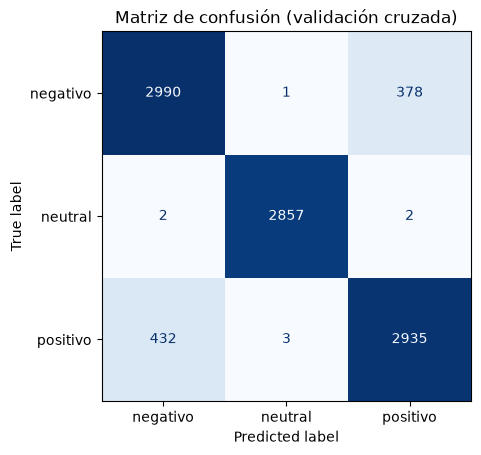

In [10]:
def validar(modelo):
    """Validación cruzada de 5 pliegues sobre entrenamiento: accuracy por pliegue y predicción fuera de pliegue de cada reseña."""
    res = cross_validate(modelo, X_ent, y_ent, cv=CV, n_jobs=-1, return_estimator=True, return_indices=True)
    pred = pd.Series(index=X_ent.index, dtype=object)
    for estimador, idx in zip(res["estimator"], res["indices"]["test"]):
        pred.iloc[idx] = estimador.predict(X_ent.iloc[idx])
    acc = res["test_score"]
    print(f"Accuracy en validación cruzada: {acc.mean():.4f} ± {acc.std():.4f}   (pliegues: {np.round(acc, 4)})")
    print(f"F1 macro: {f1_score(y_ent, pred, average='macro'):.4f}\n")
    print(classification_report(y_ent, pred, labels=LABELS, digits=3))
    ConfusionMatrixDisplay.from_predictions(y_ent, pred, labels=LABELS, cmap="Blues", colorbar=False)
    plt.title("Matriz de confusión (validación cruzada)"); plt.show()
    return acc.mean(), pred


acc_cv, pred_cv = validar(modelo)

In [11]:
def desglose(y_real, y_pred, indecisas, titulo):
    """Errores separados según la reseña tenga o no una frase de cierre indeciso."""
    error = np.asarray(y_pred) != np.asarray(y_real)
    print(f"{titulo}: {error.sum()} errores de {len(error)}")
    print(f"  con cierre indeciso: {error[indecisas].sum():>4} de {indecisas.sum():>5}  (acierto {1 - error[indecisas].mean():.3f})")
    print(f"  resto:               {error[~indecisas].sum():>4} de {(~indecisas).sum():>5}  (acierto {1 - error[~indecisas].mean():.3f})")


desglose(y_ent, pred_cv, indecisas_ent, "Validación cruzada")

Validación cruzada: 818 errores de 9600
  con cierre indeciso:  524 de  1193  (acierto 0.561)
  resto:                294 de  8407  (acierto 0.965)


**Resultado.** Accuracy **0,9148 ± 0,0066** (F1 macro 0,919; 818 errores de 9.600), frente a 0,9130 (835 errores) de la iteración 13 en los mismos pliegues y en la misma máquina.
- `negativo` F1 0,880, `positivo` 0,878, `neutral` 0,999.
- **Dónde están los errores.** 524 de los 818 están en las 1.193 reseñas con cierre indeciso, donde se acierta el 56 %: poco más que una moneda. En las otras 8.407 se acierta el 96,5 %, y de esos 294 errores la gran mayoría son reseñas de la misma zona pero sin frase de cierre (dos frases hechas opuestas). Fuera de la zona quedan 41 errores, frente a 47 de la iteración 13.
- **Qué tan segura es la mejora.** +0,18 puntos en el total no es significativo por sí solo, porque el total lo domina el azar de la zona. Lo que respalda el cambio es la tabla del inicio: menos errores fuera de la zona en las cuatro particiones (205 → 175).
- **Reproducibilidad.** La primera celda fija 1 hilo en las librerías numéricas antes de importar numpy y scikit-learn, igual que en la iteración 13.

## 5. Evaluación en la prueba
Se evalúa en el 20 % apartado. Es la cuarta vez que se mira la prueba (iteraciones 10, 12, 13 y esta) y **ninguna decisión se tomó con ella**: el modelo se eligió con validación cruzada en cuatro particiones del entrenamiento. La cifra se reporta solo como estimación final.

Accuracy en validación cruzada: 0.9148
Accuracy en la prueba:          0.9150

              precision    recall  f1-score   support

    negativo      0.870     0.891     0.880       843
     neutral      1.000     0.999     0.999       715
    positivo      0.888     0.868     0.878       842

    accuracy                          0.915      2400
   macro avg      0.919     0.919     0.919      2400
weighted avg      0.915     0.915     0.915      2400

Prueba: 204 errores de 2400
  con cierre indeciso:  140 de   317  (acierto 0.558)
  resto:                 64 de  2083  (acierto 0.969)


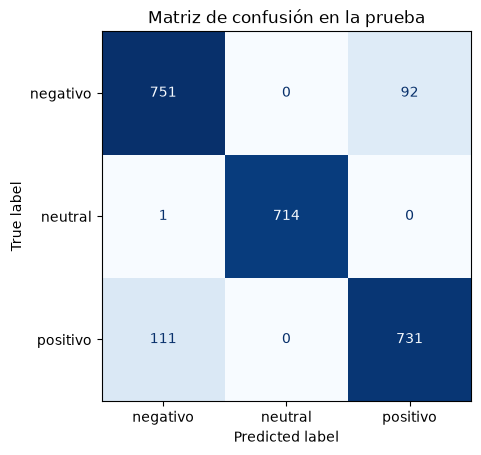

In [12]:
# n_jobs=-1 solo acelera el entrenamiento; este modelo no se guarda (el que se guarda se entrena en la sección 6)
modelo_prueba = clone(modelo).set_params(n_jobs=-1).fit(X_ent, y_ent)
pred_prueba = modelo_prueba.predict(X_prueba)
print(f"Accuracy en validación cruzada: {acc_cv:.4f}")
print(f"Accuracy en la prueba:          {accuracy_score(y_prueba, pred_prueba):.4f}\n")
print(classification_report(y_prueba, pred_prueba, labels=LABELS, digits=3))
desglose(y_prueba, pred_prueba, ~sin_cierre(X_prueba), "Prueba")
ConfusionMatrixDisplay.from_predictions(y_prueba, pred_prueba, labels=LABELS, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión en la prueba"); plt.show()

**Resultado en la prueba:** **0,9150** (204 errores de 2.400), frente a 0,9142 de la iteración 13, 0,9075 de la 12 y 0,9083 de la 10. Coincide con la validación cruzada (0,9148).
- La diferencia con la iteración 13 son 2 reseñas, muy por debajo del margen de error de la prueba (±0,6 puntos). La prueba no distingue entre las dos iteraciones y no se usó para elegir.
- Reseñas con cierre indeciso: 55,8 % de acierto (140 errores de 317). Resto: 96,9 % (64 errores de 2.083). Es el mismo patrón que en la validación cruzada.

## 6. Envío a Kaggle y modelo guardado
Se reentrena con **todo** `train.csv`, se predice `eval.csv`, se valida el formato (`id,answer`, 3.000 ids, etiquetas válidas) y se guardan el envío y el modelo. Al final se recarga el `.joblib` y se comprueba que reproduce el envío. El entrenamiento final se hace en un solo proceso para que el modelo se pueda guardar con `joblib`.

In [13]:
NOMBRE = "iter14_bases_sin_indecisas"

modelo_final = clone(modelo).fit(train["text"], train["label"])  # todo train.csv (12.000 reseñas)
envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo_final.predict(eval_df["text"])})

assert list(envio.columns) == ["id", "answer"]
assert len(envio) == 3000 and envio["id"].is_unique and set(envio["id"]) == set(muestra["id"])
assert envio["answer"].isin(LABELS).all()

ruta_envio = ENVIOS_DIR / f"{NOMBRE}.csv"
ruta_modelo = MODELOS_DIR / f"{NOMBRE}.joblib"
envio.to_csv(ruta_envio, index=False)
joblib.dump(modelo_final, ruta_modelo, compress=3)

# Replicabilidad: el modelo guardado reproduce exactamente el envío
recargado = joblib.load(ruta_modelo)
assert (recargado.predict(eval_df["text"]) == pd.read_csv(ruta_envio)["answer"].values).all()
print(f"Envío: {ruta_envio.relative_to(RAIZ)} | modelo: {ruta_modelo.relative_to(RAIZ)} "
      f"({ruta_modelo.stat().st_size / 1e6:.1f} MB)")
print("Predicciones por clase:", envio["answer"].value_counts().to_dict())
print("El modelo recargado reproduce el envío: OK")

# Solo descriptivo (no se ajusta nada con eval): diferencia con el envío anterior y reseñas con cierre indeciso
anterior = pd.read_csv(ENVIOS_DIR / "iter13_sin_relleno_polaridad.csv")
assert (anterior["id"].values == envio["id"].values).all()
print(f"Predicciones distintas de las de la iteración 13: {(anterior['answer'].values != envio['answer'].values).sum()} de 3000")
print(f"Reseñas con cierre indeciso: {(~sin_cierre(train['text'])).mean():.1%} de train.csv y "
      f"{(~sin_cierre(eval_df['text'])).mean():.1%} de eval.csv")

Envío: kaggle_iteraciones/iter14_bases_sin_indecisas.csv | modelo: models/iteraciones/iter14_bases_sin_indecisas.joblib (37.8 MB)
Predicciones por clase: {'positivo': 1121, 'negativo': 1055, 'neutral': 824}
El modelo recargado reproduce el envío: OK
Predicciones distintas de las de la iteración 13: 148 de 3000


Reseñas con cierre indeciso: 12.6% de train.csv y 14.0% de eval.csv


**Qué esperar en Kaggle.** Alrededor de 0,905-0,91. El envío cambia 148 de las 3.000 predicciones respecto a la iteración 13, que sacó 0,90666 en el leaderboard público.
- `eval.csv` tiene algo más de reseñas con cierre indeciso que `train.csv` (14,0 % frente a 12,6 %), así que el techo en Kaggle es un poco más bajo que en la validación.
- El score público se calcula con unas 900 reseñas, y cerca de 170 están en la zona de moneda al aire. Eso mueve el score unos ±0,7 puntos por puro azar entre modelos igual de buenos. Esta iteración puede quedar por encima o por debajo de la 13 en el leaderboard público sin que eso diga cuál es mejor; el puesto entre los equipos de arriba depende en buena parte de esa suerte.

## Historial de iteraciones
Accuracy en validación cruzada (5 pliegues sobre el 80 % de entrenamiento) y score público de Kaggle. Línea base trivial: 0,351.

| # | Iteración | Accuracy CV | Cambio (puntos) | Score público |
|---|---|---|---|---|
| 01 | Bolsa de palabras + Naive Bayes | 0,7047 | — | 0,68888 |
| 02 | TF-IDF + regresión logística | 0,7252 | +2,0 | 0,73555 |
| 03 | TF-IDF + Random Forest | 0,6760 | −4,9 | 0,67888 |
| 04 | Regresión logística ajustada (GridSearchCV) | 0,7407 | +6,5 | 0,75000 |
| 05 | Stacking clásico (logística + SVM + Naive Bayes) | 0,7420 | +0,1 | 0,75222 |
| 06 | Solo la última oración | 0,8509 | +10,9 | 0,84777 |
| 07 | Solo lo que va después del último conector | 0,8316 | −1,9 | 0,83555 |
| 08 | Texto completo + tras el conector + última oración | 0,8869 | +5,5 | 0,88111 |
| 09 | Stacking de vistas (metamodelo logístico) | 0,8942 | +0,7 | 0,89111 |
| 10 | Stacking ampliado con metamodelo de boosting | 0,9012 | +0,7 | 0,89888 |
| 11 | NB-SVM + negación + última cláusula en las vistas de palabras | 0,9076 | +0,6 | no enviado |
| 12 | NB-SVM también en los n-gramas de caracteres | 0,9093 | +0,2 | 0,89333 |
| 13 | Dos modelos base más: final sin relleno y polaridad por segmento | 0,9123 | +0,3 | 0,90666 |
| 14 | Una segunda copia de cada modelo base, entrenada sin las reseñas indecisas | **0,9148** | +0,2 | pendiente |

Las iteraciones 01 a 13 se midieron en otra máquina. La 13, reejecutada en la máquina de esta iteración, da 0,9130 (835 errores): cambia el tercer decimal porque la librería numérica es otra. El cambio de la 14 se calcula contra ese 0,9130.